In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
#FAIRNESS
# I want to show that fairness results in different objective value.
# Also only for GA, who takes it into account I can see difference in the solution

df = pd.read_csv("./results/fairness.csv")

In [12]:
tmp = df[["N", "method", "fairness" ,"objective"]]

In [14]:
tmp.groupby(by=["N", "method", "fairness"]).mean().reset_index()

,N,method,fairness,objective
0,50,BS,gini,1429.314
1,50,BS,jain,1427.332
2,50,BS,maxmin,1431.156
3,50,DC,gini,1586.950
4,50,DC,jain,1569.920
5,50,DC,maxmin,1590.802
6,50,GA,gini,1198.446
7,50,GA,jain,1182.780
8,50,GA,maxmin,1204.920
9,50,RC,gini,1832.068


Data Overview:
                                                path   N method     duration  \
0  ../instances/50/test/instance53_nreq50_nveh2_g...  50     DC     0.449608   
1  ../instances/50/test/instance53_nreq50_nveh2_g...  50     RC     0.665746   
2  ../instances/50/test/instance53_nreq50_nveh2_g...  50     BS     4.660200   
3  ../instances/50/test/instance53_nreq50_nveh2_g...  50     GA  2531.390000   
4  ../instances/50/test/instance58_nreq50_nveh2_g...  50     DC     0.505337   

   objective fairness  min  max  mean       std  
0    1822.78     jain    2   42  22.0  28.28430  
1    1727.83     jain    2   42  22.0  28.28430  
2    1498.84     jain   22   22  22.0   0.00000  
3    1178.00     jain   19   25  22.0   4.24264  
4    1644.37     jain    1   44  22.5  30.40560  
Unique N: [  50  100  500 1000]
Unique Methods: ['DC' 'RC' 'BS' 'GA']
Unique Fairness: ['jain' 'maxmin' 'gini']
Shape: (240, 10)

Kruskal-Wallis Results:
       N method  kw_p_value  significant  num_fair

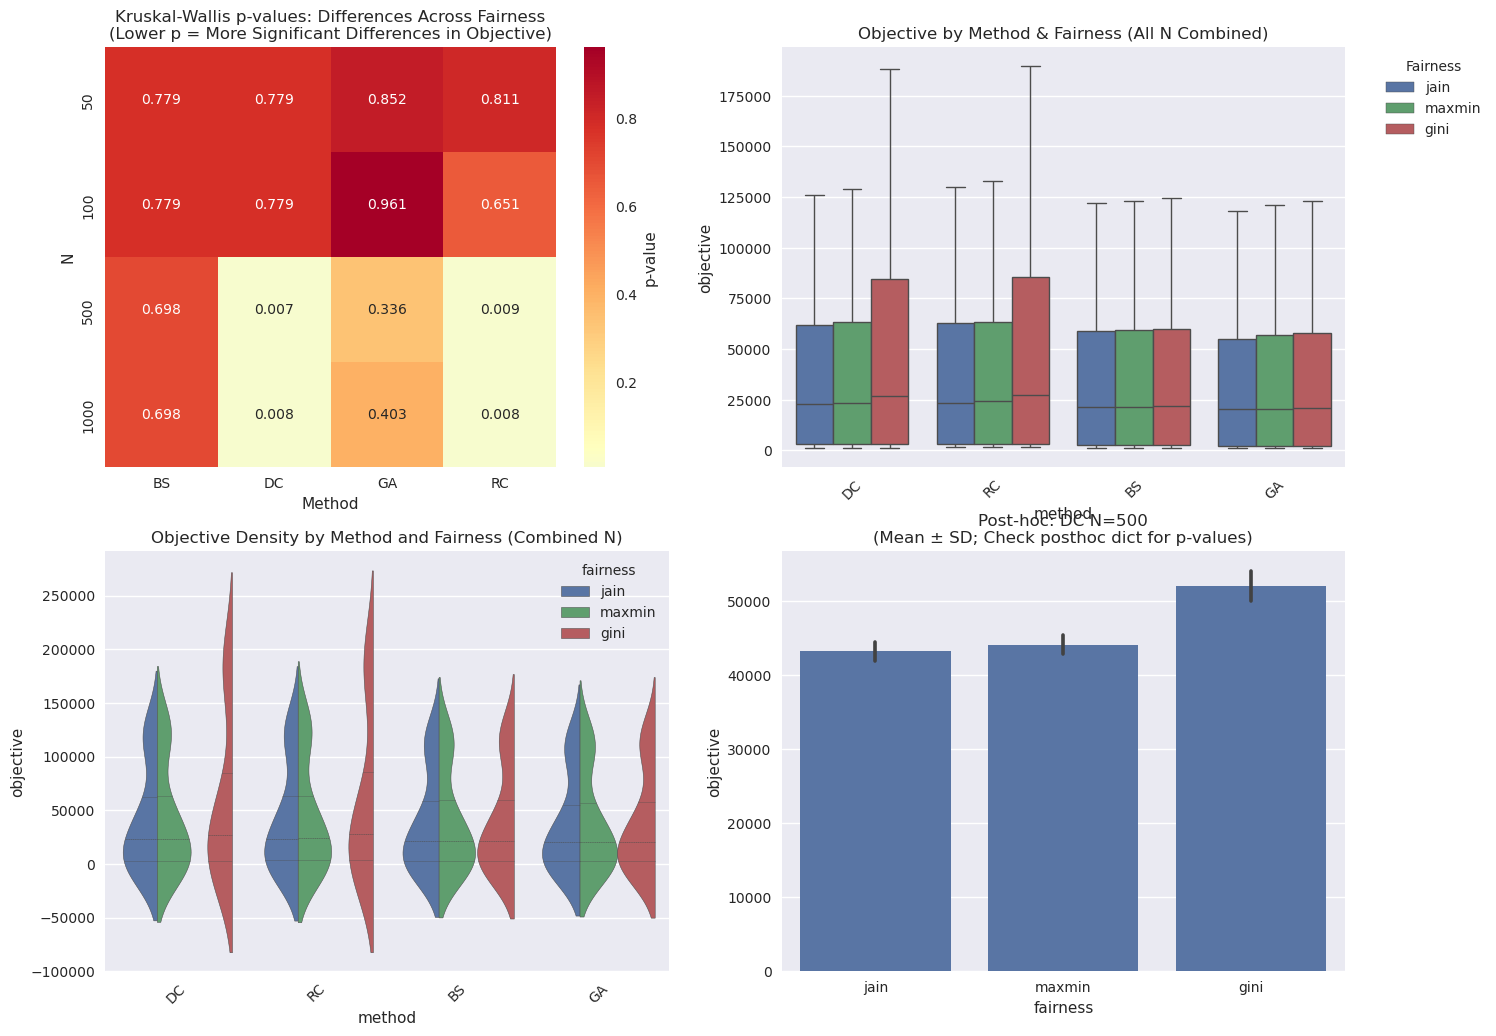

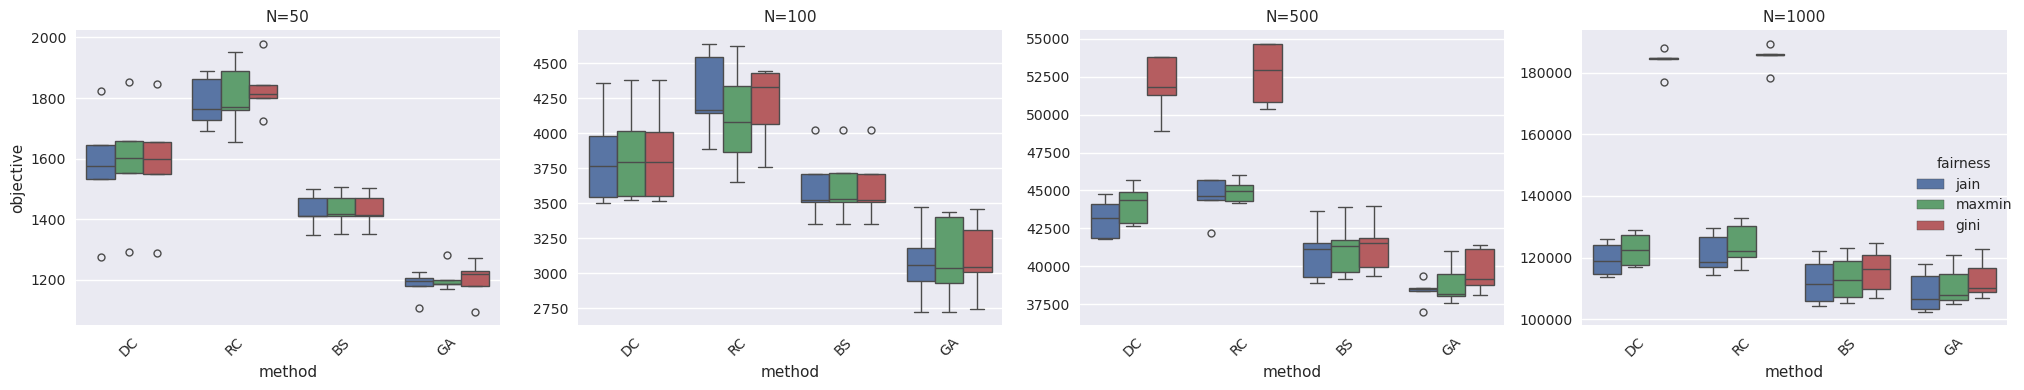

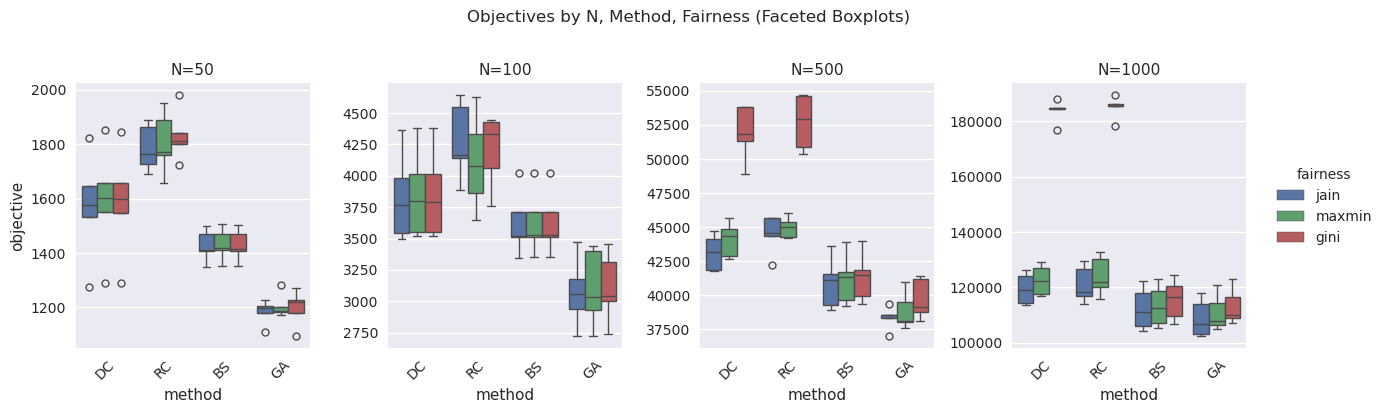


Exported: kruskal_results.csv and analysis_plots.png


In [17]:
import pandas as pd
import numpy as np
from scipy import stats
import scikit_posthocs as sp  # For post-hoc Dunn's test
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load and Prepare Data
df = pd.read_csv("./results/fairness.csv")  # Replace with your CSV path

# Clean up: Strip spaces in 'method', ensure numeric types
df['method'] = df['method'].str.strip()
df['N'] = pd.to_numeric(df['N'])
df['objective'] = pd.to_numeric(df['objective'])
df['duration'] = pd.to_numeric(df['duration'])
df['min'] = pd.to_numeric(df['min'])
df['max'] = pd.to_numeric(df['max'])
df['mean'] = pd.to_numeric(df['mean'])
df['std'] = pd.to_numeric(df['std'])

print("Data Overview:")
print(df.head())
print(f"Unique N: {df['N'].unique()}")
print(f"Unique Methods: {df['method'].unique()}")
print(f"Unique Fairness: {df['fairness'].unique()}")
print(f"Shape: {df.shape}")

# 2. Statistical Testing: Kruskal-Wallis per N + Method
results = []
for n_val in sorted(df['N'].unique()):
    for method in sorted(df['method'].unique()):
        subset = df[(df['N'] == n_val) & (df['method'] == method)]
        if len(subset) < 6:  # Skip if too few total samples (need at least 2 per group ideally)
            print(f"Skipping {n_val}-{method}: Only {len(subset)} samples")
            continue
        
        # Extract objectives by fairness: Dict of fairness -> np.array of objectives
        fairness_groups = {}
        for fairness in subset['fairness'].unique():
            objectives = subset[subset['fairness'] == fairness]['objective'].values
            if len(objectives) >= 2:  # Need at least 2 for meaningful test
                fairness_groups[fairness] = objectives
        
        if len(fairness_groups) < 2:
            print(f"Skipping {n_val}-{method}: Fewer than 2 fairness groups with >=2 samples")
            continue
        
        # Kruskal-Wallis: H-stat, p-value for differences across fairness groups
        objectives_list = list(fairness_groups.values())
        kw_stat, kw_p = stats.kruskal(*objectives_list)
        
        # Post-hoc: Dunn's test (pairwise, Bonferroni-corrected) if significant
        posthoc_p = None
        if kw_p < 0.05:
            fairness_labels = list(fairness_groups.keys())
            # Create a temp DF for post-hoc: group_id and values
            temp_data = []
            for i, (fair, objs) in enumerate(fairness_groups.items()):
                for obj in objs:
                    temp_data.append({'group': fair, 'value': obj})
            temp_df = pd.DataFrame(temp_data)
            dunn_p = sp.posthoc_dunn(temp_df, val_col='value', group_col='group', p_adjust='bonferroni')
            posthoc_p = dunn_p.to_dict()  # Dict of {fair1-fair2: pval}
        
        results.append({
            'N': n_val,
            'method': method,
            'kw_p_value': kw_p,
            'significant': kw_p < 0.05,
            'num_fairness_groups': len(fairness_groups),
            'posthoc': posthoc_p,
            'sample_sizes': {k: len(v) for k, v in fairness_groups.items()}
        })

# Create p-value summary DataFrame
pval_df = pd.DataFrame(results)
print("\nKruskal-Wallis Results:")
print(pval_df[['N', 'method', 'kw_p_value', 'significant', 'num_fairness_groups']])

# Pivot for heatmap: p-values by N (rows) and method (cols)
pivot_pvals = pval_df.pivot(index='N', columns='method', values='kw_p_value')
print("\nPivoted p-values (NaN = skipped due to low samples):")
print(pivot_pvals)

# 3. Visualization (FIXED: No col+ax conflict; uses catplot for facets)
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A: Heatmap (unchanged, works fine)
sns.heatmap(pivot_pvals, annot=True, cmap='RdYlBu_r', center=0.05, ax=axes[0,0],
            fmt='.3f', cbar_kws={'label': 'p-value'})
axes[0,0].set_title('Kruskal-Wallis p-values: Differences Across Fairness\n(Lower p = More Significant Differences in Objective)')
axes[0,0].set_xlabel('Method')
axes[0,0].set_ylabel('N')

# B: Boxplot FIXED - Use catplot for N-facets (or flatten to single plot)
g_box = sns.catplot(data=df, x='method', y='objective', hue='fairness', col='N', 
                    kind='box', height=4, aspect=1.2, sharey=False)
g_box.set_titles('N={col_name}')
g_box.set_xticklabels(rotation=45)
g_box.tight_layout()
# Note: catplot returns FacetGrid (no ax=), so it makes its own figs. To overlay, save & add later.

# For single ax version (no facets): 
sns.boxplot(data=df, x='method', y='objective', hue='fairness', ax=axes[0,1])
axes[0,1].set_title('Objective by Method & Fairness (All N Combined)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend(title='Fairness', bbox_to_anchor=(1.05, 1), loc='upper left')

# C: Violin plot (add split=True, but no col; fine as-is)
sns.violinplot(data=df, x='method', y='objective', hue='fairness', split=True, inner='quart', ax=axes[1,0])
axes[1,0].set_title('Objective Density by Method and Fairness (Combined N)')
axes[1,0].tick_params(axis='x', rotation=45)

# D: Post-hoc bar (unchanged, conditional)
if any(pval_df['significant']):
    sig_row = pval_df[pval_df['significant']].iloc[0]
    n_sig, method_sig = sig_row['N'], sig_row['method']
    subset_sig = df[(df['N'] == n_sig) & (df['method'] == method_sig)]
    sns.barplot(data=subset_sig, x='fairness', y='objective', ax=axes[1,1], errorbar='sd')
    axes[1,1].set_title(f'Post-hoc: {method_sig} N={n_sig}\n(Mean ± SD; Check posthoc dict for p-values)')
else:
    axes[1,1].text(0.5, 0.5, 'No Significant Differences', ha='center', transform=axes[1,1].transAxes)
    axes[1,1].set_title('Post-hoc (None Found)')

plt.tight_layout()
plt.savefig('analysis_plots_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

# EXTRA: Standalone Faceted Boxplot (Best for many N)
g = sns.catplot(data=df, x='method', y='objective', hue='fairness', col='N', col_wrap=4,
                kind='box', height=4, aspect=0.8, sharey=False)
g.set_titles('N={col_name}')
g.set_xticklabels(rotation=45)
g.fig.suptitle('Objectives by N, Method, Fairness (Faceted Boxplots)', y=1.02)
g.tight_layout()
g.savefig('faceted_boxplots.png', dpi=300)
plt.show()

# Optional: Export results
pval_df.to_csv('kruskal_results.csv', index=False)
print("\nExported: kruskal_results.csv and analysis_plots.png")


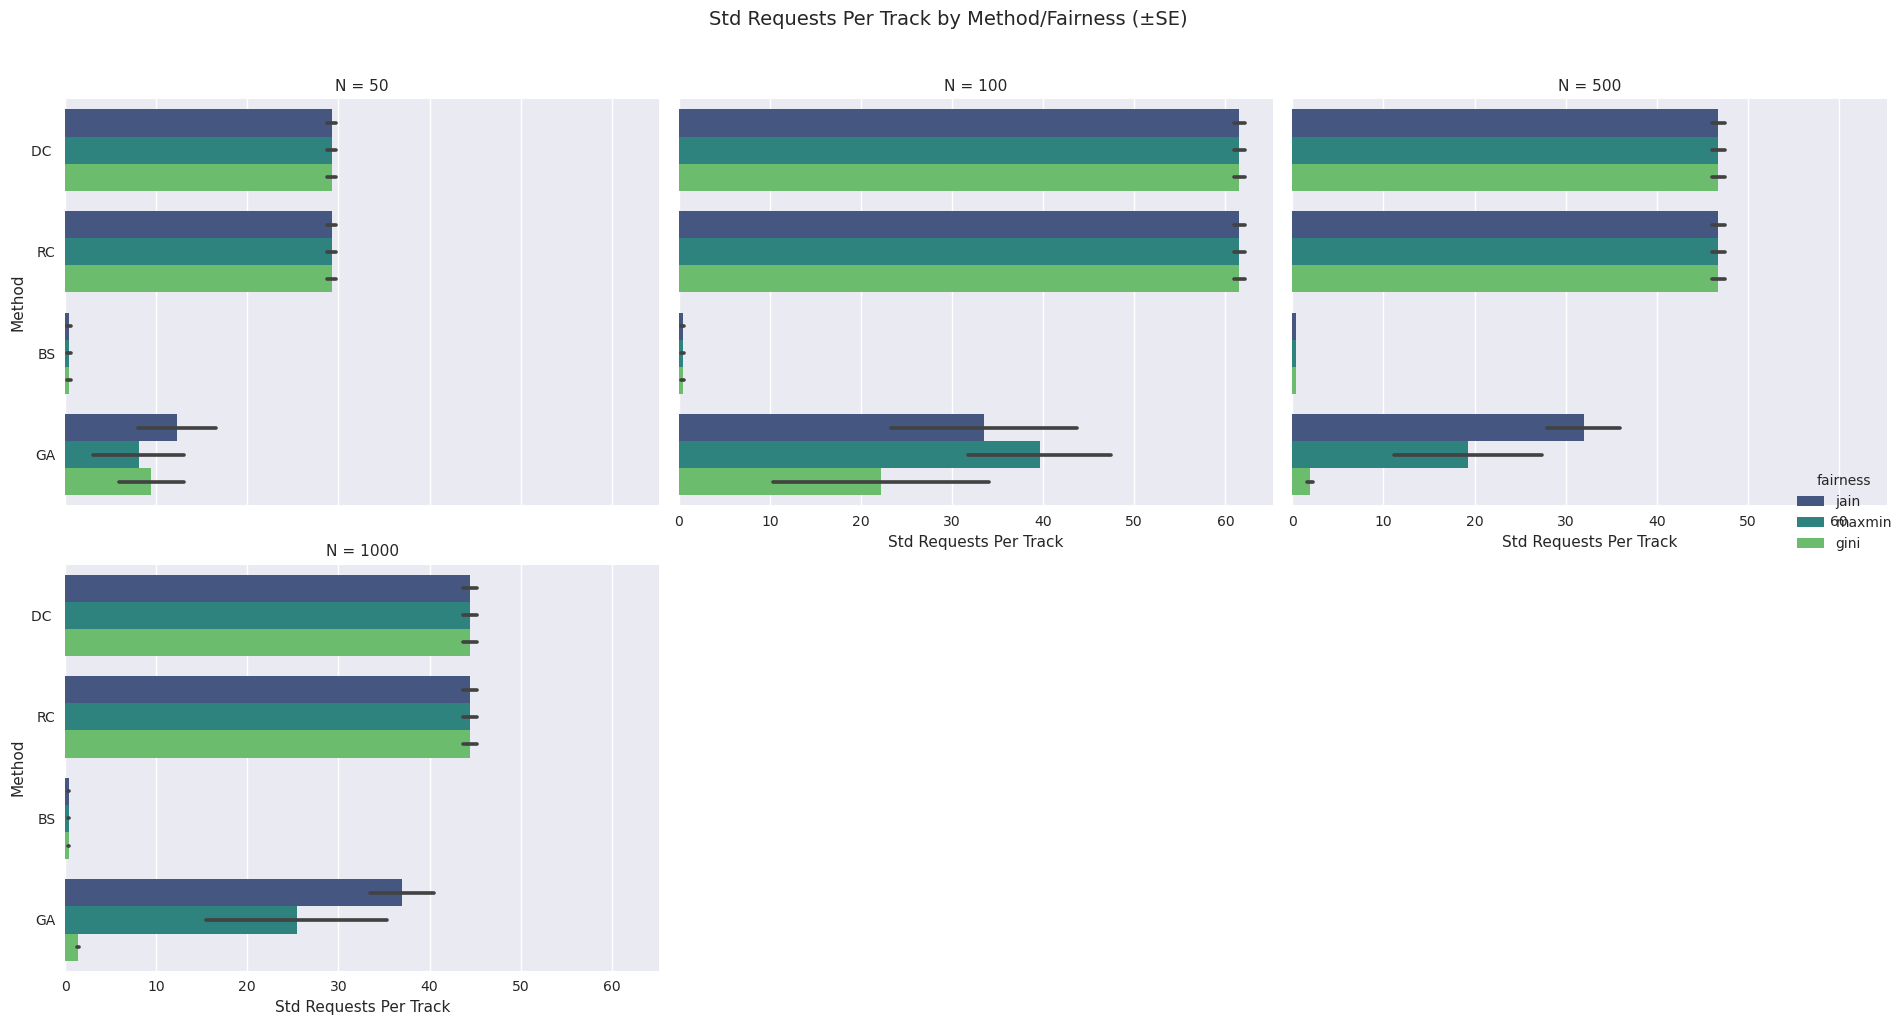

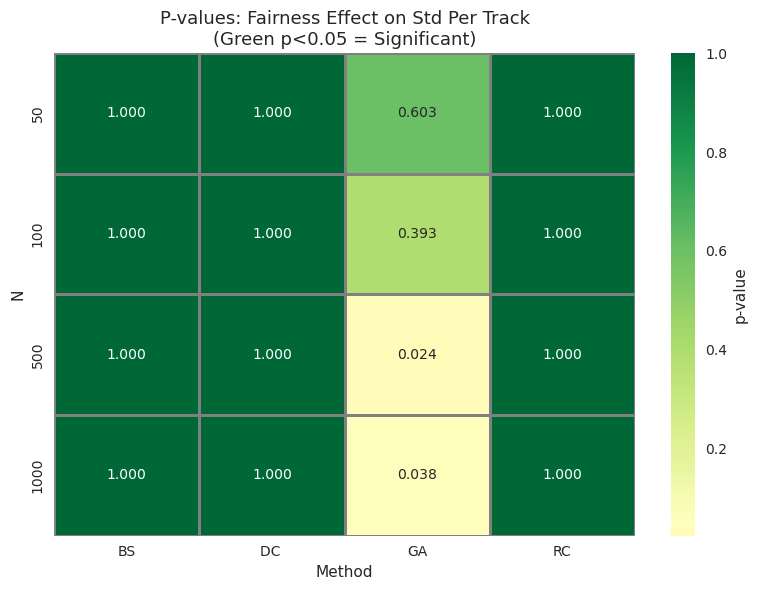

✅ Significant Results (p<0.05) - Fairness affects Std Per Track:
       N method   p_value
11   500     GA  0.023993
15  1000     GA  0.038325


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import kruskal

# 1. BARPLOT: Std Requests Per Track (FIXED: Readable method names)
g = sns.catplot(data=df, y='method', x='std', hue='fairness', col='N',  # Swapped x/y
                kind='bar', errorbar='se', col_wrap=3,
                height=5, aspect=1.2, palette='viridis', orient='h')
g.set_titles('N = {col_name}')
g.set_axis_labels('Std Requests Per Track', 'Method')
g.fig.suptitle('Std Requests Per Track by Method/Fairness (±SE)', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('std_per_track_barplot.png', dpi=300, bbox_inches='tight')
plt.show()


# 2. P-VALUE HEATMAP: Does Fairness Affect STD Per Track?
pval_std = []
for n in df['N'].unique():
    for method in df['method'].unique():
        subset = df[(df['N'] == n) & (df['method'] == method)]
        groups = [subset[subset['fairness'] == f]['std'].values 
                  for f in subset['fairness'].unique() if len(subset[subset['fairness'] == f]) > 0]
        
        if len(groups) >= 2 and all(len(g) > 0 for g in groups):
            _, p = kruskal(*groups)
        else:
            p = 1.0
        pval_std.append({'N': n, 'method': method, 'p_value': p})

pval_std_df = pd.DataFrame(pval_std)
pivot_pval_std = pval_std_df.pivot(index='N', columns='method', values='p_value')

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_pval_std, annot=True, cmap='RdYlGn', center=0.05, fmt='.3f',
            cbar_kws={'label': 'p-value'}, linewidths=1, linecolor='gray')
plt.title('P-values: Fairness Effect on Std Per Track\n(Green p<0.05 = Significant)', fontsize=13)
plt.xlabel('Method')
plt.ylabel('N')
plt.tight_layout()
plt.savefig('pvalue_heatmap_std_per_track.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary
print("✅ Significant Results (p<0.05) - Fairness affects Std Per Track:")
print(pval_std_df[pval_std_df['p_value'] < 0.05])
